# Step 05 — Mock Video Evaluation

Runs the trained model on the mock videos (`data_sample/mock-videos/`):
- `Industrial-One.mp4` — warehouse packing/sorting station
- `madera.mp4` — wood/pallet manufacturing with forklift

Renders an annotated video with bounding boxes, action labels, and confidence scores.

Note: The mock videos use a **different camera setup** than InHARD (no IMU harness, different angles, real-world CCTV). This tests generalization.

In [9]:
import sys
from pathlib import Path
NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, Video

In [10]:
from lib.paths import CHECKPOINTS_DIR, OUTPUTS_DIR, list_mock_videos

mock_videos = list_mock_videos()
print(f'Found {len(mock_videos)} mock video(s):')
for v in mock_videos:
    cap  = cv2.VideoCapture(str(v))
    fps  = cap.get(cv2.CAP_PROP_FPS)
    fc   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    print(f'  {v.name}: {w}×{h}  {fps:.0f}fps  {fc} frames  ({fc/fps:.1f}s)')

ckpts = sorted(CHECKPOINTS_DIR.glob('har_vjepa_*.pt'))
if ckpts:
    checkpoint = ckpts[-1]
    print(f'\nCheckpoint: {checkpoint.name}')
else:
    print('No checkpoint — run notebook 03 first.')

Found 1 mock video(s):
  Madera-1.mp4: 1920×1080  15fps  555 frames  (37.0s)

Checkpoint: har_vjepa_12c_topdown_allavail.pt


In [11]:
# Render annotated eval video for each mock
from lib.eval_video import render_eval_video

for video_path in mock_videos:
    out_path = OUTPUTS_DIR / f'v2_eval_{video_path.stem}.mp4'
    print(f'\nRendering {video_path.name} → {out_path.name} …')
    stats = render_eval_video(
        video_path    = video_path,
        checkpoint    = checkpoint,
        output_path   = out_path,
        max_frames    = 600,
        infer_every   = 16,
        buffer_frames = 32,
        dwell_windows = 2,
        min_confidence= 0.25,
    )
    print(f'  frames processed : {stats.get("frames_processed", "?")}')  
    print(f'  detections       : {stats.get("n_detections", "?")}')  
    print(f'  output           : {out_path}')


Rendering Madera-1.mp4 → v2_eval_Madera-1.mp4 …
  frames processed : ?
  detections       : ?
  output           : /Users/cpanoh/Documents/cpano-98-local/GitHub/AI-Co-Pilot-for-the-Production-Floor-See-Guide-Improve/har-research/outputs/v2_eval_Madera-1.mp4


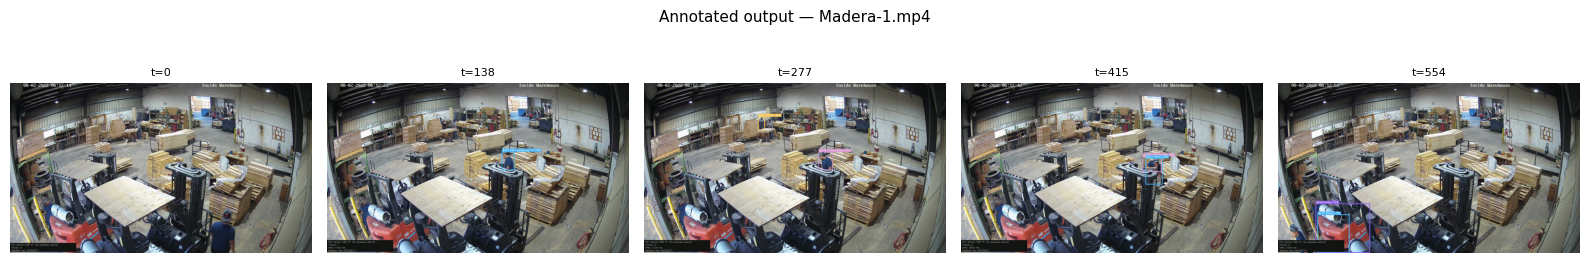

In [12]:
# Show thumbnail frames from each rendered video
for video_path in mock_videos:
    out_path = OUTPUTS_DIR / f'v2_eval_{video_path.stem}.mp4'
    if not out_path.is_file():
        continue
    cap = cv2.VideoCapture(str(out_path))
    fc  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, fc-1, 5, dtype=int)
    fig, axes = plt.subplots(1, 5, figsize=(16, 3))
    for ax, idx in zip(axes, indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.axis('off')
        ax.set_title(f't={idx}', fontsize=8)
    cap.release()
    fig.suptitle(f'Annotated output — {video_path.name}', fontsize=11)
    plt.tight_layout()
    plt.show()

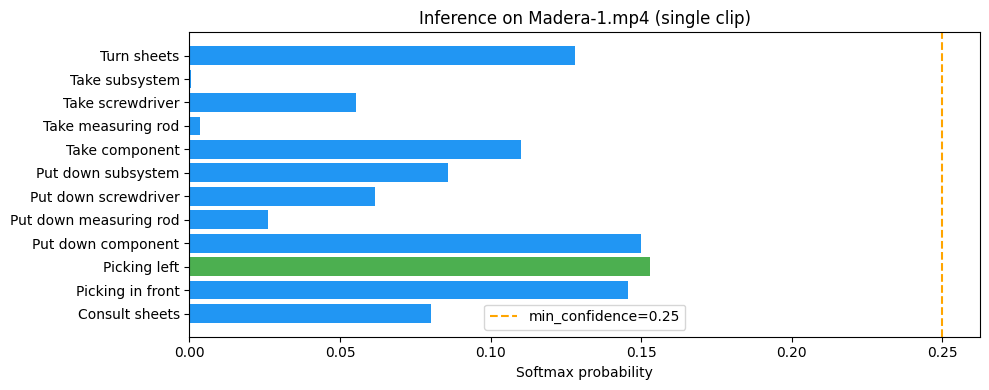

Top prediction: Picking left (15.3%)
  (below min_confidence — would show as uncertain in eval video)


In [13]:
# Inference statistics — confidence distribution
from lib.inference import HarPredictor
from lib.crop_extract import crops_for_embedding_with_meta

predictor = HarPredictor(checkpoint, min_confidence=0.25)
class_names = predictor.class_names

for video_path in mock_videos[:1]:  # run on first mock
    meta = crops_for_embedding_with_meta(video_path, mode='full_clip', max_read=64)
    crops = meta['crops']
    if len(crops) < 4:
        continue
    pred = predictor.predict_from_crops(crops)
    probs = np.array([pred['all_probs'][name] for name in class_names])

    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['#4CAF50' if p == probs.max() else '#2196F3' for p in probs]
    ax.barh(class_names, probs, color=colors)
    ax.axvline(0.25, color='orange', ls='--', lw=1.5, label='min_confidence=0.25')
    ax.set_xlabel('Softmax probability')
    ax.set_title(f'Inference on {video_path.name} (single clip)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f'Top prediction: {pred["raw_label"]} ({pred["raw_confidence"]:.1%})')
    if pred['uncertain']:
        print('  (below min_confidence — would show as uncertain in eval video)')

## Live preview — detection dashboard

Set **`UI_MODE`** below, then run this cell.

| `UI_MODE` | What you see |
|-----------|----------------|
| `'dashboard'` | **Recommended** — video + YOLO boxes + tracked persons list + per-track action stats |
| `'video'` | Annotated video playback only |
| `'file'` | Replay saved `v2_eval_*.mp4` (run render cell first) |

Also writes a session log → **`08_Session_Log_Review.ipynb`** for tagging.

In [15]:
from lib.video_preview import launch_eval_dashboard, play_inference_notebook, play_video_notebook

# ══════════════════════════════════════════════════════════════════════════════
# UI_MODE — pick one:
#   'dashboard'  → YOLO detection + track list + action stats per person (best)
#   'video'      → annotated playback only
#   'file'       → replay pre-rendered mp4
# ══════════════════════════════════════════════════════════════════════════════
UI_MODE            = 'dashboard'

PREVIEW_INDEX      = 0          # 0 = first mock video, 1 = second, …
MAX_FRAMES         = 600
INFER_EVERY        = 16
MIN_CONFIDENCE     = 0.25
RUN_OPENCV_WINDOW  = False      # True → separate OS window (q quit)

video_path = mock_videos[PREVIEW_INDEX]
out_path   = OUTPUTS_DIR / f'v2_eval_{video_path.stem}.mp4'

print(f'UI_MODE     : {UI_MODE}')
print(f'Source      : {video_path.name}')
print(f'Checkpoint  : {checkpoint.name}')
print('-' * 50)

if UI_MODE == 'dashboard':
    launch_eval_dashboard(
        video_path,
        checkpoint,
        width=720,
        max_frames=MAX_FRAMES,
        infer_every=INFER_EVERY,
        min_confidence=MIN_CONFIDENCE,
        log_session=True,
    )
elif UI_MODE == 'video':
    play_inference_notebook(
        video_path,
        checkpoint,
        width=960,
        max_frames=MAX_FRAMES,
        infer_every=INFER_EVERY,
        min_confidence=MIN_CONFIDENCE,
    )
elif UI_MODE == 'file':
    if not out_path.is_file():
        raise FileNotFoundError(
            f'Missing {out_path.name} — run the render cell above first.'
        )
    print(f'Replaying: {out_path.name}')
    play_video_notebook(out_path, width=960)
else:
    raise ValueError(f"Unknown UI_MODE={UI_MODE!r} — use 'dashboard', 'video', or 'file'")

if RUN_OPENCV_WINDOW:
    from lib.live_app import run_live
    print(f'\nOpening OpenCV window: {video_path.name}')
    run_live(
        checkpoint=checkpoint,
        video=video_path,
        webcam=None,
        infer_every=INFER_EVERY,
        buffer_frames=32,
        dwell_windows=2,
        max_seconds=None,
        min_confidence=MIN_CONFIDENCE,
    )